In [3]:
import pandas as pd

data = pd.read_csv("/content/binary_classification_moons.csv")
data.head(6)

,X1,X2,label
0,-0.009332,0.390981,1
1,0.954574,-0.473756,1
2,0.918526,-0.425196,1
3,0.412768,-0.376385,1
4,-0.845320,0.528799,0
5,0.579542,-0.352979,1


In [4]:
data.describe()

,X1,X2,label
count,1000.000000,1000.000000,1000.00000
mean,0.499552,0.249196,0.50000
std,0.867371,0.494822,0.50025
min,-1.061751,-0.571697,0.00000
25%,-0.019860,-0.216408,0.00000
50%,0.502008,0.248686,0.50000
75%,1.020851,0.694288,1.00000
max,2.064637,1.042677,1.00000


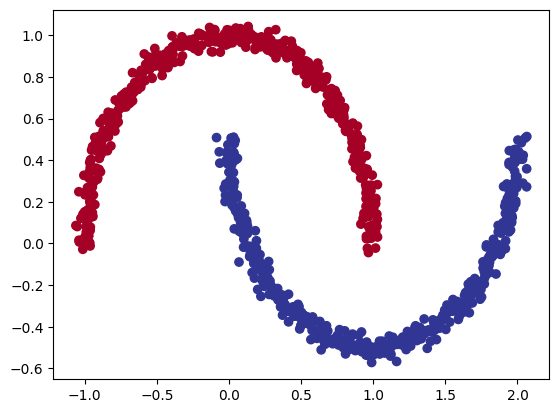

In [5]:
# Visualize with a plot
import matplotlib.pyplot as plt
plt.scatter(
            x=data.X1,
            y=data.X2,
            c=data.label,
            cmap=plt.cm.RdYlBu
            );

In [6]:
# vectorizing X1 and X2 into a single tensor/nparray

X = data[['X1', 'X2']].values
y = data['label'].values

In [7]:
print(f"First 5 X features:\n{X[:5]}")
print(f"\nFirst 5 y labels:\n{y[:5]}")

First 5 X features:
[[-0.00933187  0.39098105]
 [ 0.95457387 -0.47375583]
 [ 0.9185256  -0.42519648]
 [ 0.41276802 -0.37638459]
 [-0.84532016  0.52879908]]

First 5 y labels:
[1 1 1 1 0]


In [8]:
# Check the shapes of our features and labels
X.shape, y.shape

((1000, 2), (1000,))

In [9]:
# Turn data into tensors
# Otherwise this causes issues with computations later on
import torch
X = torch.from_numpy(X).type(torch.float)
y = torch.from_numpy(y).type(torch.float)

# View the first five samples
X[:5], y[:5]

(tensor([[-0.0093,  0.3910],
         [ 0.9546, -0.4738],
         [ 0.9185, -0.4252],
         [ 0.4128, -0.3764],
         [-0.8453,  0.5288]]),
 tensor([1., 1., 1., 1., 0.]))

In [10]:
# Split data into train and test sets
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.2, # 20% test, 80% train
                                                    random_state=42) # make the random split reproducible

len(X_train), len(X_test), len(y_train), len(y_test)

(800, 200, 800, 200)

In [11]:
# Standard PyTorch imports
import torch
from torch import nn

# Make device agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [12]:
# 1. Construct a model class that subclasses nn.Module
class ModelV0(nn.Module):
    def __init__(self):
        super().__init__()
        # 2. Create 2 nn.Linear layers capable of handling X and y input and output shapes
        self.layer_1 = nn.Linear(in_features=2, out_features=5) # takes in 2 features (X), produces 5 features
        self.layer_2 = nn.Linear(in_features=5, out_features=1) # takes in 5 features, produces 1 feature (y)

    # 3. Define a forward method containing the forward pass computation
    def forward(self, x):
        # Return the output of layer_2, a single feature, the same shape as y
        return self.layer_2(self.layer_1(x)) # computation goes through layer_1 first then the output of layer_1 goes through layer_2

# 4. Create an instance of the model and send it to target device
model_0 = ModelV0().to(device)
model_0

ModelV0(
  (layer_1): Linear(in_features=2, out_features=5, bias=True)
  (layer_2): Linear(in_features=5, out_features=1, bias=True)
)

In [13]:
model = model_0

In [14]:
# Make predictions with the model
untrained_preds = model(X_test.to(device))
print(f"Length of predictions: {len(untrained_preds)}, Shape: {untrained_preds.shape}")
print(f"Length of test samples: {len(y_test)}, Shape: {y_test.shape}")
print(f"\nFirst 10 predictions:\n{untrained_preds[:10]}")
print(f"\nFirst 10 test labels:\n{y_test[:10]}")

Length of predictions: 200, Shape: torch.Size([200, 1])
Length of test samples: 200, Shape: torch.Size([200])

First 10 predictions:
tensor([[-0.2263],
        [-0.2978],
        [-0.3252],
        [-0.2851],
        [-0.4262],
        [-0.4465],
        [-0.3161],
        [-0.3137],
        [-0.3102],
        [-0.2920]], grad_fn=<SliceBackward0>)

First 10 test labels:
tensor([1., 0., 1., 0., 1., 1., 0., 0., 1., 0.])


In [15]:
# Create a loss function
# loss_fn = nn.BCELoss() # BCELoss = no sigmoid built-in
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

In [16]:
# View the frist 5 outputs of the forward pass on the test data
y_logits = model(X_test.to(device))[:5]
y_logits

tensor([[-0.2263],
        [-0.2978],
        [-0.3252],
        [-0.2851],
        [-0.4262]], grad_fn=<SliceBackward0>)

In [17]:
# Use sigmoid on model logits
y_pred_probs = torch.sigmoid(y_logits)
y_pred_probs

tensor([[0.4437],
        [0.4261],
        [0.4194],
        [0.4292],
        [0.3950]], grad_fn=<SigmoidBackward0>)

In [18]:
# Find the predicted labels (round the prediction probabilities)
y_preds = torch.round(y_pred_probs)

# In full
y_pred_labels = torch.round(torch.sigmoid(model(X_test.to(device))[:5]))

# Check for equality
print(torch.eq(y_preds.squeeze(), y_pred_labels.squeeze()))

# Get rid of extra dimension
y_preds.squeeze()

tensor([True, True, True, True, True])


tensor([0., 0., 0., 0., 0.], grad_fn=<SqueezeBackward0>)

In [19]:
y_test[:5]

tensor([1., 0., 1., 0., 1.])

In [20]:
torch.manual_seed(42)

# Set the number of epochs
epochs = 100

# Put data to target device
X_train, y_train = X_train.to(device), y_train.to(device)
X_test, y_test = X_test.to(device), y_test.to(device)


In [21]:
from utils import train_and_test_loop

train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

Epoch: 0 | Loss: 0.73154, Accuracy: 50.00% | Test loss: 0.71675, Test acc: 50.00%
Epoch: 10 | Loss: 0.65328, Accuracy: 77.62% | Test loss: 0.65231, Test acc: 71.50%
Epoch: 20 | Loss: 0.60065, Accuracy: 76.12% | Test loss: 0.60681, Test acc: 75.00%
Epoch: 30 | Loss: 0.54974, Accuracy: 77.25% | Test loss: 0.56135, Test acc: 75.00%
Epoch: 40 | Loss: 0.49912, Accuracy: 77.75% | Test loss: 0.51540, Test acc: 76.50%
Epoch: 50 | Loss: 0.45290, Accuracy: 79.12% | Test loss: 0.47286, Test acc: 77.00%
Epoch: 60 | Loss: 0.41445, Accuracy: 80.38% | Test loss: 0.43678, Test acc: 79.00%
Epoch: 70 | Loss: 0.38440, Accuracy: 81.38% | Test loss: 0.40779, Test acc: 79.00%
Epoch: 80 | Loss: 0.36144, Accuracy: 81.62% | Test loss: 0.38489, Test acc: 79.50%
Epoch: 90 | Loss: 0.34378, Accuracy: 82.38% | Test loss: 0.36660, Test acc: 80.50%


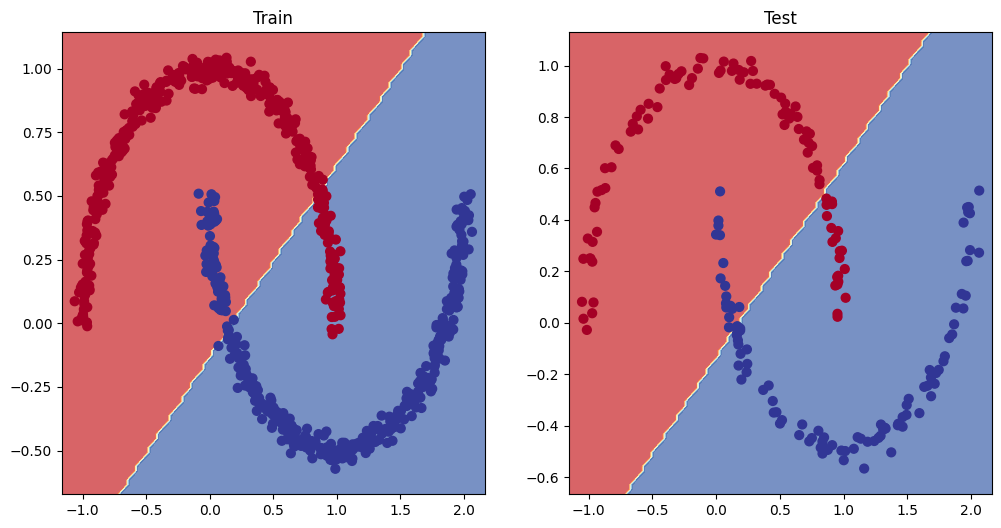

In [22]:
from utils import plot_decision_boundary

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

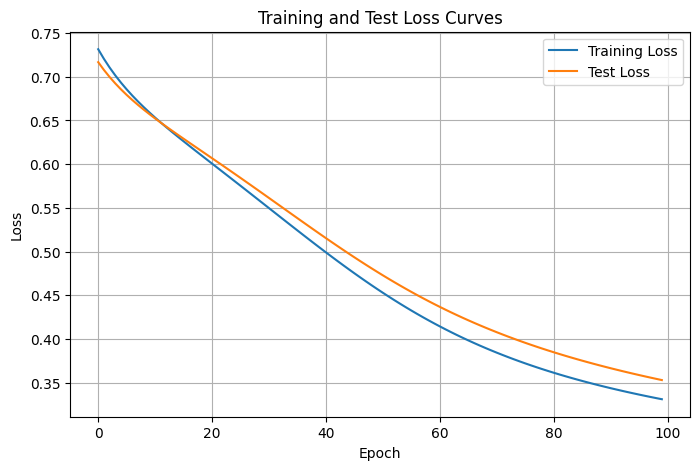

In [23]:

import matplotlib.pyplot as plt

def plot_loss_curves(train_losses, test_losses):
    """
    Plots training and testing loss curves.

    Args:
        train_losses (list): Loss values from training
        test_losses (list): Loss values from testing
    """
    epochs = range(len(train_losses))

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, train_losses, label="Training Loss")
    plt.plot(epochs, test_losses, label="Test Loss")

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Training and Test Loss Curves")
    plt.legend()
    plt.grid(True)
    plt.show()

plot_loss_curves(train_losses, test_losses)

In [24]:
class ModelV1(nn.Module):
    def __init__(self):
        super().__init__()
        self.layer_1 = nn.Linear(in_features=2, out_features=10)
        self.layer_2 = nn.Linear(in_features=10, out_features=10)
        self.layer_3 = nn.Linear(in_features=10, out_features=1)

    def forward(self, x): # note: always make sure forward is spelt correctly!
        # Creating a model like this is the same as below, though below
        # generally benefits from speedups where possible.
        # z = self.layer_1(x)
        # z = self.layer_2(z)
        # z = self.layer_3(z)
        # return z
        return self.layer_3(self.layer_2(self.layer_1(x)))

model_1 = ModelV1().to(device)
model_1

ModelV1(
  (layer_1): Linear(in_features=2, out_features=10, bias=True)
  (layer_2): Linear(in_features=10, out_features=10, bias=True)
  (layer_3): Linear(in_features=10, out_features=1, bias=True)
)

In [25]:
model = model_1
epochs = 1000

# Create a loss function
loss_fn = nn.BCEWithLogitsLoss() # BCEWithLogitsLoss = sigmoid built-in

# Create an optimizer
optimizer = torch.optim.SGD(params=model.parameters(),
                            lr=0.1)

Epoch: 0 | Loss: 0.71976, Accuracy: 30.75% | Test loss: 0.70134, Test acc: 45.50%
Epoch: 10 | Loss: 0.58674, Accuracy: 79.62% | Test loss: 0.58552, Test acc: 78.00%
Epoch: 20 | Loss: 0.47594, Accuracy: 79.62% | Test loss: 0.48700, Test acc: 77.00%
Epoch: 30 | Loss: 0.39832, Accuracy: 81.00% | Test loss: 0.41841, Test acc: 77.00%
Epoch: 40 | Loss: 0.35499, Accuracy: 81.62% | Test loss: 0.37773, Test acc: 78.00%
Epoch: 50 | Loss: 0.32886, Accuracy: 82.62% | Test loss: 0.35055, Test acc: 80.50%
Epoch: 60 | Loss: 0.31010, Accuracy: 83.75% | Test loss: 0.32940, Test acc: 82.00%
Epoch: 70 | Loss: 0.29513, Accuracy: 84.75% | Test loss: 0.31171, Test acc: 83.50%
Epoch: 80 | Loss: 0.28276, Accuracy: 85.00% | Test loss: 0.29670, Test acc: 85.50%
Epoch: 90 | Loss: 0.27260, Accuracy: 85.62% | Test loss: 0.28413, Test acc: 86.50%
Epoch: 100 | Loss: 0.26443, Accuracy: 86.25% | Test loss: 0.27384, Test acc: 87.50%
Epoch: 110 | Loss: 0.25803, Accuracy: 87.00% | Test loss: 0.26561, Test acc: 87.50%
Epo

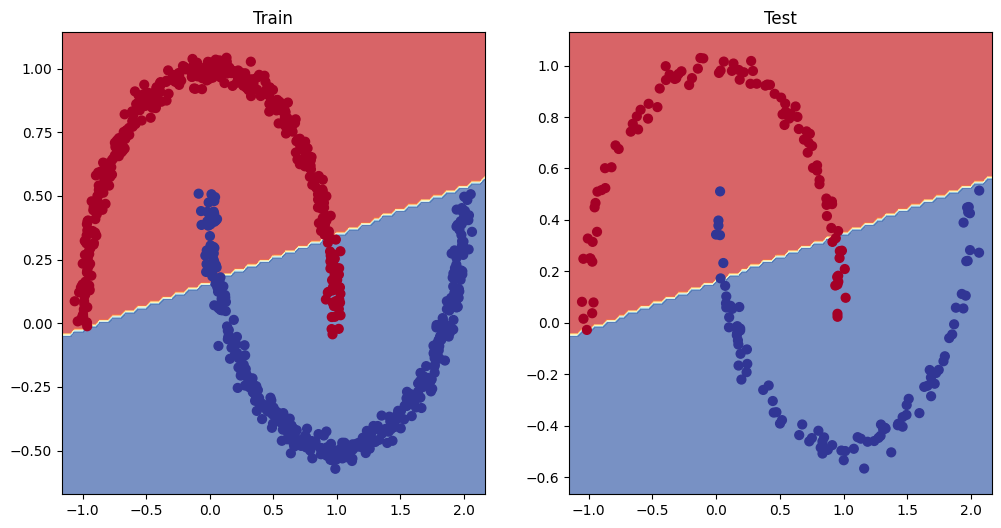

In [26]:
train_losses, acc_list, test_losses, test_acc = train_and_test_loop(
    model=model,
    epochs=epochs,
    X_train=X_train,
    y_train=y_train,
    X_test=X_test,
    y_test=y_test,
    loss_fn=loss_fn,
    optimizer=optimizer
)

# Plot decision boundaries for training and test sets
plt.figure(figsize=(12, 6))
plt.subplot(1, 2, 1)
plt.title("Train")
plot_decision_boundary(model, X_train, y_train)
plt.subplot(1, 2, 2)
plt.title("Test")
plot_decision_boundary(model, X_test, y_test)

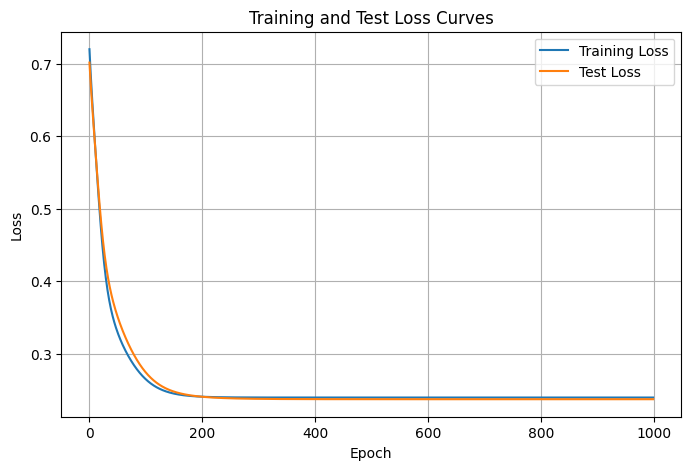

In [27]:
plot_loss_curves(train_losses, test_losses)